# Simulation deuxieme partie du stage


In [3]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy.stats as stats
from typing import Tuple, Optional


class RandomNetwork:
    """
    Classe pour générer un réseau bancaire aléatoire avec NetworkX.
    Supporte différentes topologies : Erdős-Rényi, Small World, Scale-Free.
    """

    def __init__(self, number_bank: int, topology: str = "erdos_renyi",
                 probability_of_linking: float = 0.5, **topology_params):
        """
        Initialise le générateur de réseau.

        :param number_bank: Nombre de banques
        :param topology: Type de réseau ("erdos_renyi", "small_world", "scale_free")
        :param probability_of_linking: Probabilité de création de liens
        :param topology_params: Paramètres spécifiques à la topologie
        """
        self.number_bank = number_bank
        self.topology = topology
        self.probability_of_linking = probability_of_linking
        self.topology_params = topology_params

        # Structures de données
        self.graph = None
        self.vector_outside_liabilities = None
        self.vector_outside_asset = None
        self.matrix_obligation = None
        self.matrix_relative_exposures = None  # Matrice relative d'exposition

        # Génération automatique
        self.generate()

    def generate(self):
        """
        Génère le réseau et les bilans bancaires selon la topologie choisie.
        """
        # 1. Génération du graphe selon la topologie
        if self.topology == "erdos_renyi":
            self.graph = self._generate_erdos_renyi()
        elif self.topology == "small_world":
            self.graph = self._generate_small_world()
        elif self.topology == "scale_free":
            self.graph = self._generate_scale_free()
        else:
            raise ValueError(f"Topologie non supportée: {self.topology}")

        # 2. Initialisation des structures
        n = self.number_bank
        self.vector_outside_liabilities = np.zeros(n)
        self.vector_outside_asset = np.zeros(n)
        self.matrix_obligation = np.zeros((n, n))

        # 3. Génération des passifs externes
        for i in range(n):
            if np.random.random() < self.probability_of_linking:
                self.vector_outside_liabilities[i] = stats.gamma.rvs(a=150)

        # 4. Génération des obligations interbancaires
        for i, j in self.graph.edges():
            self.matrix_obligation[i][j] = stats.gamma.rvs(a=150)

        # 5. Calcul et équilibrage des bilans
        self._balance_sheets()

    def _generate_erdos_renyi(self):
        """Génère un graphe Erdős-Rényi dirigé."""
        return nx.erdos_renyi_graph(
            n=self.number_bank,
            p=self.probability_of_linking,
            directed=True
        )

    def _generate_small_world(self):
        """
        Génère un graphe Small World (Watts-Strogatz) dirigé.
        Paramètres par défaut: k=4, p=0.3
        """
        k = self.topology_params.get('k', self.number_bank//4)  # Nombre de voisins proches
        p = self.topology_params.get('p', 0.5)  # Probabilité de rewiring

        # Générer le graphe non-dirigé puis le convertir
        undirected_graph = nx.watts_strogatz_graph(self.number_bank, k, p)

        # Conversion en graphe dirigé avec probabilité
        directed_graph = nx.DiGraph()
        directed_graph.add_nodes_from(range(self.number_bank))

        for u, v in undirected_graph.edges():
            # Chaque arête non-dirigée devient dirigée avec probabilité
            if np.random.random() < 0.5:
                directed_graph.add_edge(u, v)
            else:
                directed_graph.add_edge(v, u)

            # Possibilité d'arête bidirectionnelle
            if np.random.random() < self.probability_of_linking:
                if directed_graph.has_edge(u, v):
                    directed_graph.add_edge(v, u)
                else:
                    directed_graph.add_edge(u, v)

        return directed_graph

    def _generate_scale_free(self):
        """
        Génère un graphe Scale-Free (Barabási-Albert) dirigé.
        Paramètres par défaut: m=2
        """
        m = self.topology_params.get('m', 4)  # Nombre d'arêtes ajoutées à chaque étape

        # Générer le graphe non-dirigé puis le convertir
        undirected_graph = nx.barabasi_albert_graph(self.number_bank, m)

        # Conversion en graphe dirigé
        directed_graph = nx.DiGraph()
        directed_graph.add_nodes_from(range(self.number_bank))

        for u, v in undirected_graph.edges():
            # Direction aléatoire pour chaque arête
            if np.random.random() < 0.5:
                directed_graph.add_edge(u, v)
            else:
                directed_graph.add_edge(v, u)

            # Possibilité d'arête bidirectionnelle basée sur les degrés (attachement préférentiel)
            degree_factor = (undirected_graph.degree(u) + undirected_graph.degree(v)) / (2 * self.number_bank)
            if np.random.random() < degree_factor * self.probability_of_linking:
                if directed_graph.has_edge(u, v):
                    directed_graph.add_edge(v, u)
                else:
                    directed_graph.add_edge(u, v)

        return directed_graph

    def _balance_sheets(self):
        """
        Équilibre les bilans en générant les actifs externes appropriés.
        Calcule aussi la matrice relative d'exposition.
        """
        # Calcul des totaux par banque
        je_dois = np.sum(self.matrix_obligation, axis=1)  # Passifs internes
        on_me_doit = np.sum(self.matrix_obligation, axis=0)  # Actifs internes

        # Génération des actifs externes selon la règle de compensation
        for i in range(self.number_bank):
            deficit_total = je_dois[i] + self.vector_outside_liabilities[i] - on_me_doit[i]

            if deficit_total > 0:
                # Banque en déficit : compensation + marge
                self.vector_outside_asset[i] = deficit_total + stats.gamma.rvs(a=200)
            else:
                # Banque excédentaire : actifs externes de base
                self.vector_outside_asset[i] = stats.gamma.rvs(a=200)

        # Calcul de la matrice relative d'exposition (une seule fois)
        self._compute_relative_exposures()

    def _compute_relative_exposures(self):
        """
        Calcule la matrice relative d'exposition.
        matrix_relative_exposures[i,j] = obligation[i,j] / total_dû_par_i
        """
        self.matrix_relative_exposures = np.zeros_like(self.matrix_obligation)

        for i in range(self.number_bank):
            total_du_par_i = np.sum(self.matrix_obligation[i, :])
            if total_du_par_i > 0:
                self.matrix_relative_exposures[i, :] = self.matrix_obligation[i, :] / total_du_par_i

    def compute_clearing_payments(self, shock_vector: np.array,
                                tolerance: float = 1e-9) -> np.array:
        """
        Calcule les paiements d'équilibre selon Eisenberg-Noe.

        :param shock_vector: Vecteur des chocs externes
        :param tolerance: Tolérance de convergence
        :return: Vecteur des paiements d'équilibre
        """
        # Paiements dus (somme des obligations de chaque banque)
        due_payments = np.sum(self.matrix_obligation, axis=1)

        # Initialisation
        vector_of_payments = due_payments.copy()

        if np.all(shock_vector == 0):
            return vector_of_payments

        # Itération d'Eisenberg-Noe
        while True:
            # Calcul des nouveaux paiements
            new_vector_of_payments = np.minimum(
                due_payments,
                np.maximum(
                    self.matrix_relative_exposures.T @ vector_of_payments
                    - shock_vector
                    + self.vector_outside_asset,
                    0
                )
            )

            # Test de convergence
            if np.allclose(new_vector_of_payments, vector_of_payments, rtol=tolerance):
                return new_vector_of_payments

            vector_of_payments = new_vector_of_payments



    def get_updated_obligation_matrix(self, payments_vector: np.array) -> np.array:
        """
        Calcule la matrice d'obligations actualisée après clearing.

        :param payments_vector: Vecteur des paiements d'équilibre
        :return: Matrice d'obligations actualisée
        """
        # Utilisation de la matrice relative d'exposition
        updated_matrix = np.zeros_like(self.matrix_obligation)

        for i in range(self.number_bank):
            # Chaque banque i paie payments_vector[i] réparti selon ses expositions relatives
            updated_matrix[i, :] = payments_vector[i] * self.matrix_relative_exposures[i, :]

        return updated_matrix

    def get_net_worth_after_clearing(self, shock_vector: Optional[np.array] = None) -> Tuple[np.array, np.array]:
        """
        Calcule le net worth de chaque banque après le clearing d'Eisenberg-Noe.

        :param shock_vector: Vecteur de chocs (optionnel)
        :return: Tuple (net_worth, payments_vector)
        """
        if shock_vector is None:
            shock_vector = np.zeros(self.number_bank)

        # Calcul du vecteur de paiements d'équilibre
        payments = self.compute_clearing_payments(shock_vector)

        # Matrice d'obligations actualisée
        updated_obligations = self.get_updated_obligation_matrix(payments)

        # Calcul des actifs internes effectivement reçus
        actifs_internes_effectifs = np.sum(updated_obligations, axis=0)

        # Net worth après clearing
        net_worth = (
            (self.vector_outside_asset - shock_vector) +  # Actifs externes après choc
            actifs_internes_effectifs -                   # Actifs internes effectivement reçus
            self.vector_outside_liabilities -             # Passifs externes
            payments                                      # Paiements effectifs
        )

        return net_worth, payments

    def count_defaults(self, shock_vector: np.array, threshold: float = 0.0) -> int:
        """
        Compte le nombre de défauts après application du choc et clearing.

        :param shock_vector: Vecteur des chocs
        :param threshold: Seuil de défaut
        :return: Nombre de banques en défaut
        """
        net_worth, _ = self.get_net_worth_after_clearing(shock_vector)
        return np.sum(net_worth <= threshold)

    def plot_connectivity_vs_defaults(self, shock_range: np.array = None):
        """
        Graphique: Connectivité en fonction du nombre de défauts.
        """
        if shock_range is None:
            shock_range = np.linspace(0, 1, 51)

        # Calcul de la connectivité (degré sortant de chaque banque)
        out_degrees = np.array([self.graph.out_degree(i) for i in range(self.number_bank)])

        # Simulation pour différents niveaux de choc
        default_counts = []
        for alpha in shock_range:
            shock_vector = alpha * self.vector_outside_asset
            defaults = self.count_defaults(shock_vector)
            default_counts.append(defaults)

        # Graphique
        plt.figure(figsize=(10, 6))
        for i in range(self.number_bank):
            # Couleur basée sur la connectivité
            color_intensity = out_degrees[i] / max(out_degrees) if max(out_degrees) > 0 else 0
            plt.scatter([shock_range[j] for j, d in enumerate(default_counts) if i < d],
                       [i] * sum(1 for d in default_counts if i < d),
                       c=plt.cm.viridis(color_intensity), s=20, alpha=0.6)

        plt.xlabel('Niveau de Choc')
        plt.ylabel('Banque (par ordre de défaut)')
        plt.title('Connectivité vs Ordre de Défaut')
        plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), label='Connectivité (normalisée)')
        plt.show()

    def plot_degree_distribution(self):
        """
        Affiche la distribution des degrés (intensité).
        """
        out_degrees = [self.graph.out_degree(i) for i in range(self.number_bank)]
        in_degrees = [self.graph.in_degree(i) for i in range(self.number_bank)]

        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

        # Distribution des degrés sortants
        ax1.hist(out_degrees, bins=20, alpha=0.7, edgecolor='black')
        ax1.set_xlabel('Degré Sortant')
        ax1.set_ylabel('Fréquence')
        ax1.set_title('Distribution des Degrés Sortants')

        # Distribution des degrés entrants
        ax2.hist(in_degrees, bins=20, alpha=0.7, edgecolor='black', color='orange')
        ax2.set_xlabel('Degré Entrant')
        ax2.set_ylabel('Fréquence')
        ax2.set_title('Distribution des Degrés Entrants')

        # Scatter plot degré sortant vs entrant
        ax3.scatter(out_degrees, in_degrees, alpha=0.6)
        ax3.set_xlabel('Degré Sortant')
        ax3.set_ylabel('Degré Entrant')
        ax3.set_title('Degré Sortant vs Entrant')

        plt.tight_layout()
        plt.show()

    def plot_topology_comparison(self, shock_level: float = 0.5):
        """
        Compare les propriétés de différentes topologies.
        """
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # Graphique du réseau
        pos = nx.spring_layout(self.graph)
        nx.draw(self.graph, pos, ax=axes[0,0], with_labels=True,
                node_size=300, node_color='lightblue',
                edge_color='gray', arrows=True, arrowsize=20)
        axes[0,0].set_title(f'Réseau {self.topology.title()}')

        # Distribution des degrés
        out_degrees = [self.graph.out_degree(i) for i in range(self.number_bank)]
        in_degrees = [self.graph.in_degree(i) for i in range(self.number_bank)]

        axes[0,1].hist(out_degrees, bins=15, alpha=0.7, label='Sortant', edgecolor='black')
        axes[0,1].hist(in_degrees, bins=15, alpha=0.7, label='Entrant', edgecolor='black')
        axes[0,1].set_xlabel('Degré')
        axes[0,1].set_ylabel('Fréquence')
        axes[0,1].set_title('Distribution des Degrés')
        axes[0,1].legend()

        # Analyse de la transition de phase
        results = self.analyze_shock_transition()
        axes[1,0].plot(results['shock_levels'], results['default_proportions'], 'b-', linewidth=2)
        axes[1,0].axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Seuil 0.5')
        axes[1,0].set_xlabel('Niveau de Choc')
        axes[1,0].set_ylabel('Proportion de Défauts')
        axes[1,0].set_title('Transition de Phase')
        axes[1,0].grid(True, alpha=0.3)
        axes[1,0].legend()

        # Net Worth vs Connectivité
        shock_vector = shock_level * self.vector_outside_asset
        net_worth, _ = self.get_net_worth_after_clearing(shock_vector)
        connectivity = np.array([self.graph.out_degree(i) + self.graph.in_degree(i)
                               for i in range(self.number_bank)])
        defaults = (net_worth <= 0)

        colors = ['red' if d else 'blue' for d in defaults]
        axes[1,1].scatter(connectivity, net_worth, c=colors, alpha=0.6)
        axes[1,1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
        axes[1,1].set_xlabel('Connectivité Totale')
        axes[1,1].set_ylabel('Net Worth')
        axes[1,1].set_title(f'Net Worth vs Connectivité (choc={shock_level})')

        plt.tight_layout()
        plt.show()

    def analyze_shock_transition(self, shock_steps: int = 101) -> dict:
        """
        Analyse complète de la transition de phase.

        :param shock_steps: Nombre de pas pour l'analyse
        :return: Dictionnaire avec les résultats
        """
        shock_range = np.linspace(0, 1, shock_steps)
        results = {
            'shock_levels': shock_range,
            'default_counts': [],
            'default_proportions': []
        }

        for alpha in shock_range:
            shock_vector = alpha * self.vector_outside_asset
            defaults = self.count_defaults(shock_vector)
            results['default_counts'].append(defaults)
            results['default_proportions'].append(defaults / self.number_bank)

        return results




Génération des réseaux erdos_renyi avec différents niveaux de connectivité...
Génération des réseaux small_world avec différents niveaux de connectivité...
Génération des réseaux scale_free avec différents niveaux de connectivité...


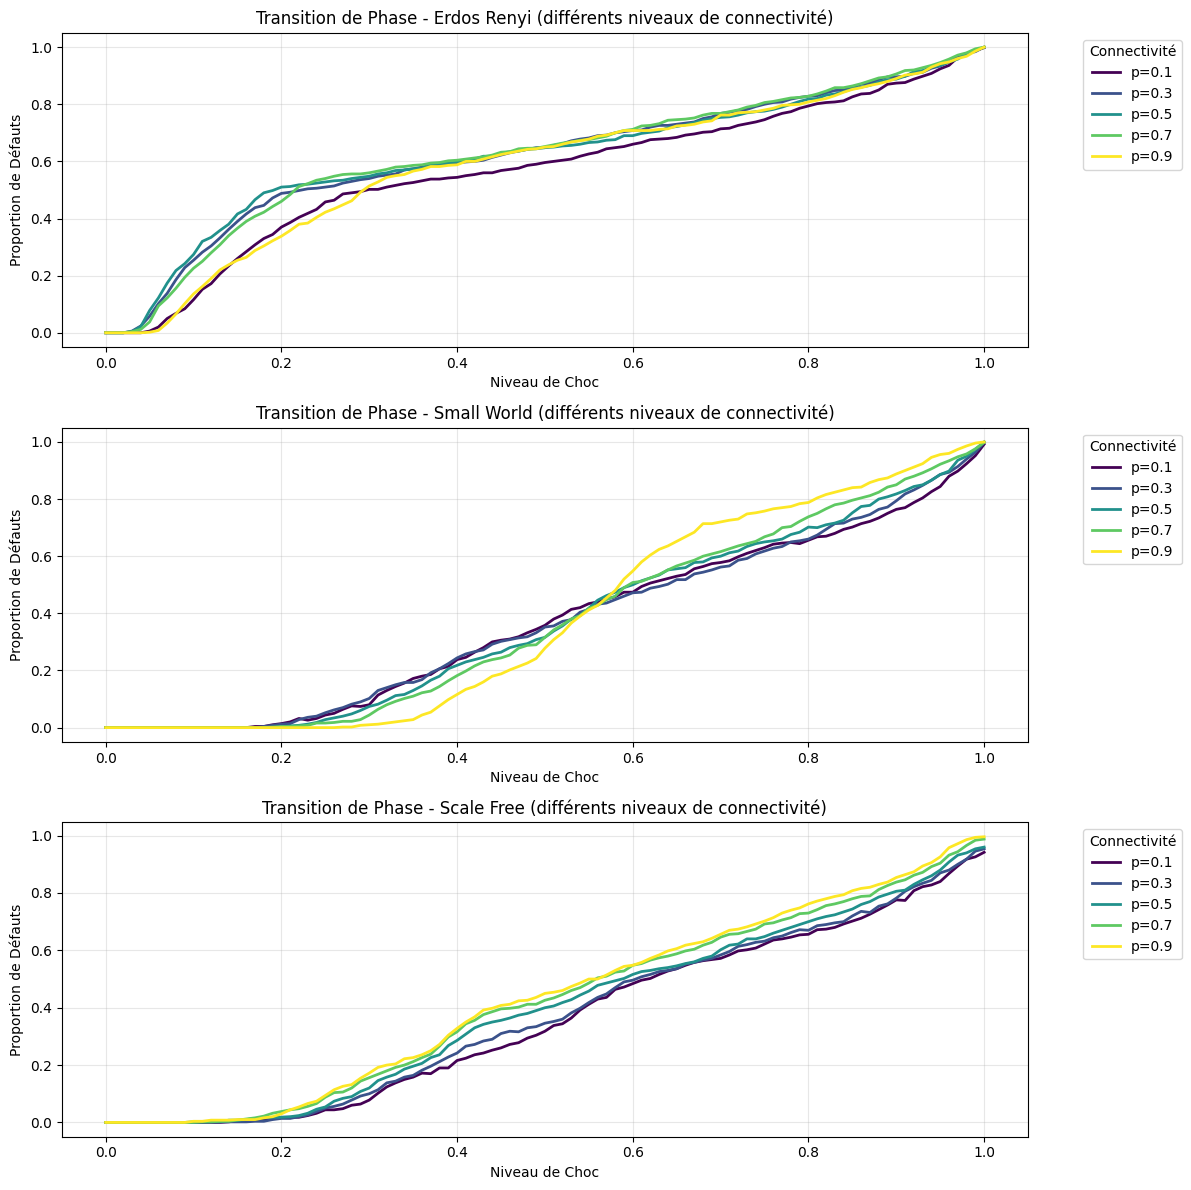


Analyse comparative globale...


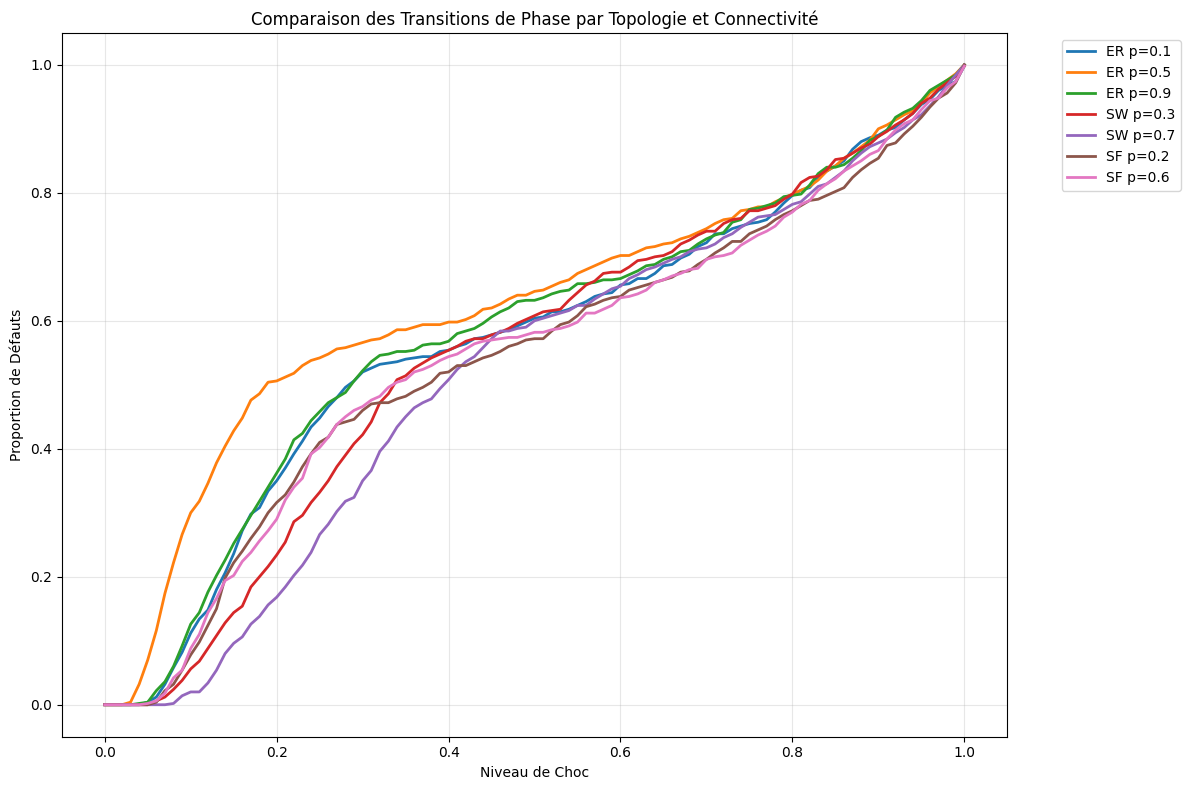

In [4]:
# Exemple d'utilisation
if __name__ == "__main__":
    # Différents niveaux de connectivité à tester
    connectivity_levels = [0.1, 0.3, 0.5, 0.7, 0.9]

    # Comparaison de différentes topologies avec niveaux de connectivité
    topologies = [
        ("erdos_renyi", {}),
        ("small_world", {"k": 6, "p": 0.3}),
        ("scale_free", {"m": 3})
    ]

    fig, axes = plt.subplots(len(topologies), 1, figsize=(12, 4*len(topologies)))
    colors = plt.cm.viridis(np.linspace(0, 1, len(connectivity_levels)))

    for i, (topology, base_params) in enumerate(topologies):
        print(f"Génération des réseaux {topology} avec différents niveaux de connectivité...")

        # Graphique pour cette topologie
        ax = axes[i] if len(topologies) > 1 else axes

        for j, prob_linking in enumerate(connectivity_levels):
            # Génération du réseau avec ce niveau de connectivité
            network = RandomNetwork(
                number_bank=500,
                topology=topology,
                probability_of_linking=prob_linking,
                **base_params
            )

            # Analyse de la transition
            results = network.analyze_shock_transition()

            # Ajout de la courbe
            ax.plot(results['shock_levels'], results['default_proportions'],
                   color=colors[j], linewidth=2,
                   label=f'p={prob_linking:.1f}')

        ax.set_xlabel('Niveau de Choc')
        ax.set_ylabel('Proportion de Défauts')
        ax.set_title(f'Transition de Phase - {topology.title().replace("_", " ")} (différents niveaux de connectivité)')
        ax.grid(True, alpha=0.3)
        ax.legend(title='Connectivité', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # Analyse comparative sur un graphique unique
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))

    # Combinaison topologie + connectivité
    test_configs = [
        ("erdos_renyi", 0.1, "ER p=0.1"),
        ("erdos_renyi", 0.5, "ER p=0.5"),
        ("erdos_renyi", 0.9, "ER p=0.9"),
        ("small_world", 0.3, "SW p=0.3"),
        ("small_world", 0.7, "SW p=0.7"),
        ("scale_free", 0.2, "SF p=0.2"),
        ("scale_free", 0.6, "SF p=0.6")
    ]

    print("\nAnalyse comparative globale...")
    for topology, prob_linking, label in test_configs:
        base_params = {}
        if topology == "small_world":
            base_params = {"k": 70, "p": 0.7}
        elif topology == "scale_free":
            base_params = {"m": 40}

        network = RandomNetwork(
            number_bank=500,
            topology=topology,
            probability_of_linking=prob_linking,
            **base_params
        )

        results = network.analyze_shock_transition()
        ax.plot(results['shock_levels'], results['default_proportions'],
               linewidth=2, label=label)

    ax.set_xlabel('Niveau de Choc')
    ax.set_ylabel('Proportion de Défauts')
    ax.set_title('Comparaison des Transitions de Phase par Topologie et Connectivité')
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

In [5]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy.stats as stats
from typing import Tuple, Optional, Dict, List
from abc import ABC, abstractmethod
from enum import Enum

In [6]:
class NetworkTopology(Enum):
    ERDOS_RENYI = "erdos_renyi"
    SMALL_WORLD = "small_world"
    SCALE_FREE = "scale_free"



In [7]:
class BankingNetwork:
    """
    Classe pour générer et gérer un réseau bancaire avec différentes topologies.
    Conserve l'implémentation NetworkX propre et le mécanisme d'Eisenberg-Noe.
    """

    def __init__(self, number_bank: int, topology: NetworkTopology,
                 probability_of_linking: float = 0.1, **topology_params):
        self.number_bank = number_bank
        self.topology = topology
        self.probability_of_linking = probability_of_linking
        self.topology_params = topology_params

        # Structures de données (conservées de l'implémentation précédente)
        self.graph = None
        self.vector_outside_liabilities = None
        self.vector_outside_asset = None
        self.matrix_obligation = None
        self.matrix_relative_exposures = None

        # Génération du réseau
        self.generate()

    def generate(self):
        """Génère le réseau selon la topologie choisie."""
        # Génération du graphe
        if self.topology == NetworkTopology.ERDOS_RENYI:
            self.graph = self._generate_erdos_renyi()
        elif self.topology == NetworkTopology.SMALL_WORLD:
            self.graph = self._generate_small_world()
        elif self.topology == NetworkTopology.SCALE_FREE:
            self.graph = self._generate_scale_free()

        # Génération des bilans (méthode conservée)
        self._generate_balance_sheets()

    def _generate_erdos_renyi(self):
        """Génère un graphe Erdős-Rényi dirigé."""
        return nx.erdos_renyi_graph(
            n=self.number_bank,
            p=self.probability_of_linking,
            directed=True
        )

    def _get_calibrated_params(self):
        """Calibre automatiquement les paramètres selon le nombre de banques."""
        target_avg_degree = self.probability_of_linking * (self.number_bank - 1)

        params = {
            NetworkTopology.SMALL_WORLD: {
                'k': max(2, int(2 * target_avg_degree)),  # k doit être pair et ≥ 2
                'p': 0.3  # Bon compromis clustering/distance
            },
            NetworkTopology.SCALE_FREE: {
                'm': max(1, int(target_avg_degree / 2))  # m ≥ 1
            }
        }

        # Override avec paramètres utilisateur si fournis
        if self.topology in params:
            params[self.topology].update(self.topology_params)
            return params[self.topology]
        return {}

    def _generate_small_world(self):
        """Génère un graphe Small World dirigé avec calibrage automatique."""
        calibrated = self._get_calibrated_params()
        k, p = calibrated['k'], calibrated['p']

        # Assure que k est valide pour la taille du réseau
        k = min(k, self.number_bank - 1)
        if k % 2 == 1: k -= 1  # k doit être pair
        if k < 2: k = 2

        undirected = nx.watts_strogatz_graph(self.number_bank, k, p)
        return self._convert_to_directed(undirected)

    def _generate_scale_free(self):
        """Génère un graphe Scale-Free dirigé avec calibrage automatique."""
        calibrated = self._get_calibrated_params()
        m = min(calibrated['m'], self.number_bank - 1)  # m < n

        undirected = nx.barabasi_albert_graph(self.number_bank, m)
        return self._convert_to_directed(undirected, preferential=True)

    def _convert_to_directed(self, undirected_graph, preferential=False):
        """Convertit un graphe non-dirigé en dirigé de manière cohérente."""
        directed = nx.DiGraph()
        directed.add_nodes_from(range(self.number_bank))

        for u, v in undirected_graph.edges():
            # Direction aléatoire pour chaque arête
            if np.random.random() < 0.5:
                directed.add_edge(u, v)
            else:
                directed.add_edge(v, u)

            # Probabilité d'arête bidirectionnelle
            if preferential:
                # Pour scale-free : probabilité basée sur les degrés
                degree_sum = undirected_graph.degree(u) + undirected_graph.degree(v)
                prob_bidirectional = min(0.5, degree_sum / (4 * self.number_bank))
            else:
                # Pour small world : probabilité fixe
                prob_bidirectional = self.probability_of_linking * 0.3

            if np.random.random() < prob_bidirectional:
                if directed.has_edge(u, v):
                    directed.add_edge(v, u)
                else:
                    directed.add_edge(u, v)

        return directed

    def _generate_balance_sheets(self):
        """Génère les bilans bancaires (méthode conservée de ton implémentation)."""
        n = self.number_bank
        self.vector_outside_liabilities = np.zeros(n)
        self.vector_outside_asset = np.zeros(n)
        self.matrix_obligation = np.zeros((n, n))

        # Génération des passifs externes
        for i in range(n):
            if np.random.random() < self.probability_of_linking:
                self.vector_outside_liabilities[i] = stats.gamma.rvs(a=150)

        # Génération des obligations interbancaires
        for i, j in self.graph.edges():
            self.matrix_obligation[i][j] = stats.gamma.rvs(a=150)

        # Équilibrage des bilans et calcul des expositions relatives
        self._balance_sheets()

    def _balance_sheets(self):
        """Méthode conservée de ton implémentation."""
        je_dois = np.sum(self.matrix_obligation, axis=1)
        on_me_doit = np.sum(self.matrix_obligation, axis=0)

        for i in range(self.number_bank):
            deficit_total = je_dois[i] + self.vector_outside_liabilities[i] - on_me_doit[i]

            if deficit_total > 0:
                self.vector_outside_asset[i] = deficit_total + stats.gamma.rvs(a=200)
            else:
                self.vector_outside_asset[i] = stats.gamma.rvs(a=200)

        self._compute_relative_exposures()

    def _compute_relative_exposures(self):
        """Calcule la matrice relative d'exposition."""
        self.matrix_relative_exposures = np.zeros_like(self.matrix_obligation)

        for i in range(self.number_bank):
            total_du_par_i = np.sum(self.matrix_obligation[i, :])
            if total_du_par_i > 0:
                self.matrix_relative_exposures[i, :] = self.matrix_obligation[i, :] / total_du_par_i

    def compute_clearing_payments(self, shock_vector: np.array,
                                tolerance: float = 1e-9) -> np.array:
        """Méthode Eisenberg-Noe conservée."""
        due_payments = np.sum(self.matrix_obligation, axis=1)
        vector_of_payments = due_payments.copy()

        if np.all(shock_vector == 0):
            return vector_of_payments

        while True:
            new_vector_of_payments = np.minimum(
                due_payments,
                np.maximum(
                    self.matrix_relative_exposures.T @ vector_of_payments
                    - shock_vector
                    + self.vector_outside_asset,
                    0
                )
            )

            if np.allclose(new_vector_of_payments, vector_of_payments, rtol=tolerance):
                return new_vector_of_payments

            vector_of_payments = new_vector_of_payments



    def get_net_worth_after_clearing(self, shock_vector: np.array) -> Tuple[np.array, np.array]:
        """Calcule le net worth après clearing (méthode conservée)."""
        payments = self.compute_clearing_payments(shock_vector)
        updated_obligations = self.get_updated_obligation_matrix(payments)

        actifs_internes_effectifs = np.sum(updated_obligations, axis=0)

        net_worth = (
            (self.vector_outside_asset - shock_vector) +
            actifs_internes_effectifs -
            self.vector_outside_liabilities -
            payments
        )

        return net_worth, payments

    def get_updated_obligation_matrix(self, payments_vector: np.array) -> np.array:
        """Matrice d'obligations actualisée après clearing."""
        updated_matrix = np.zeros_like(self.matrix_obligation)

        for i in range(self.number_bank):
            updated_matrix[i, :] = payments_vector[i] * self.matrix_relative_exposures[i, :]

        return updated_matrix

    def count_defaults(self, shock_vector: np.array, threshold: float = 0.0) -> int:
        """Compte les défauts après clearing."""
        net_worth, _ = self.get_net_worth_after_clearing(shock_vector)
        return np.sum(net_worth <= threshold)

    def compute_connectivity_metrics(self) -> Dict:
        """Calcule les métriques de connectivité pour comparaison entre topologies."""
        n = self.number_bank
        m = self.graph.number_of_edges()

        return {
            'density': m / (n * (n-1)) if n > 1 else 0,
            'avg_degree': 2*m / n if n > 0 else 0,
            'clustering': nx.average_clustering(self.graph) if n > 0 else 0,
            'max_degree': max(dict(self.graph.degree()).values()) if n > 0 else 0,
            'degree_variance': np.var(list(dict(self.graph.degree()).values())) if n > 0 else 0
        }


In [8]:
class ShockModel(ABC):
    """Classe abstraite pour les différents modèles de chocs."""

    @abstractmethod
    def generate_shock(self, network: BankingNetwork) -> Tuple[np.array, Dict]:
        """Génère un vecteur de chocs et retourne des métadonnées."""
        pass

In [9]:
class TargetedShockModel(ShockModel):
    """Modèle de choc ciblé (comme dans le papier de référence)."""

    def __init__(self, target_strategy: str = "random", shock_intensity: float = 1.0):
        self.target_strategy = target_strategy
        self.shock_intensity = shock_intensity

    def generate_shock(self, network: BankingNetwork) -> Tuple[np.array, Dict]:
        """Génère un choc ciblé sur une banque spécifique."""
        target = self._select_target(network)

        shock_vector = np.zeros(network.number_bank)
        shock_vector[target] = self.shock_intensity * network.vector_outside_asset[target]

        metadata = {
            'type': 'targeted',
            'target': target,
            'target_strategy': self.target_strategy,
            'shock_size': shock_vector[target]
        }

        return shock_vector, metadata

    def _select_target(self, network: BankingNetwork) -> int:
        """Sélectionne la banque à cibler selon la stratégie."""
        if self.target_strategy == "max_degree":
            degrees = dict(network.graph.degree())
            return max(degrees, key=degrees.get)
        elif self.target_strategy == "max_assets":
            return np.argmax(network.vector_outside_asset)
        elif self.target_strategy == "systemic":
            scores = []
            for i in range(network.number_bank):
                degree = network.graph.degree(i)
                assets = network.vector_outside_asset[i]
                scores.append(degree * assets)
            return np.argmax(scores)
        else:  # random
            return np.random.randint(0, network.number_bank)


In [10]:
class CorrelatedShockModel(ShockModel):
    """Modèle de chocs corrélés avec facteur commun."""

    def __init__(self, correlation_strength: float = 0.3, crisis_prob: float = 0.1):
        self.correlation_strength = correlation_strength
        self.crisis_prob = crisis_prob

    def generate_shock(self, network: BankingNetwork) -> Tuple[np.array, Dict]:
        """Génère des chocs corrélés."""
        n = network.number_bank

        is_crisis = np.random.random() < self.crisis_prob
        alpha = 0.7 if is_crisis else self.correlation_strength

        common_factor = np.random.pareto(2.0)
        idiosyncratic = np.random.pareto(2.0, size=n)

        shock_intensities = alpha * common_factor + (1-alpha) * idiosyncratic
        shock_intensities = shock_intensities / np.max(shock_intensities) * 0.5  # Normalisation

        shock_vector = shock_intensities * network.vector_outside_asset

        metadata = {
            'type': 'correlated',
            'is_crisis': is_crisis,
            'correlation_strength': alpha,
            'common_factor': common_factor
        }

        return shock_vector, metadata


In [11]:
class LiquidityShockModel(ShockModel):
    """Modèle de choc de liquidité avec ventes forcées."""

    def __init__(self, distress_prob: float = 0.2, fire_sale_intensity: float = 0.5):
        self.distress_prob = distress_prob
        self.fire_sale_intensity = fire_sale_intensity

    def generate_shock(self, network: BankingNetwork) -> Tuple[np.array, Dict]:
        """Génère un choc de liquidité."""
        n = network.number_bank

        distressed = np.random.random(n) < self.distress_prob
        total_fire_sales = np.sum(network.vector_outside_asset[distressed])

        if total_fire_sales > 0:
            price_impact = np.exp(-self.fire_sale_intensity * total_fire_sales /
                                np.sum(network.vector_outside_asset))
        else:
            price_impact = 1.0

        shock_vector = (1 - price_impact) * network.vector_outside_asset

        metadata = {
            'type': 'liquidity',
            'distressed_banks': distressed,
            'price_impact': price_impact,
            'total_fire_sales': total_fire_sales
        }

        return shock_vector, metadata


In [12]:
class BankingSimulator:
    """
    Classe principale pour orchestrer les simulations et analyses.
    Sépare la logique de simulation de la génération de réseaux et de chocs.
    """

    def __init__(self, network: BankingNetwork, shock_model: ShockModel):
        self.network = network
        self.shock_model = shock_model

    def single_simulation(self) -> Dict:
        """Exécute une simulation unique."""
        shock_vector, shock_metadata = self.shock_model.generate_shock(self.network)

        net_worth, payments = self.network.get_net_worth_after_clearing(shock_vector)
        defaults_count = np.sum(net_worth <= 0)

        return {
            'defaults_count': defaults_count,
            'defaults_proportion': defaults_count / self.network.number_bank,
            'net_worth': net_worth,
            'payments': payments,
            'shock_metadata': shock_metadata,
            'network_metrics': self.network.compute_connectivity_metrics()
        }

    def monte_carlo_simulation(self, n_simulations: int = 100) -> Dict:
        """Exécute n simulations Monte Carlo."""
        results = []

        for _ in range(n_simulations):
            # Régénère le réseau pour chaque simulation si nécessaire
            if hasattr(self.shock_model, 'requires_network_regeneration'):
                if self.shock_model.requires_network_regeneration:
                    self.network.generate()

            result = self.single_simulation()
            results.append(result)

        return self._aggregate_results(results)

    def _aggregate_results(self, results: List[Dict]) -> Dict:
        """Agrège les résultats des simulations Monte Carlo."""
        defaults_counts = [r['defaults_count'] for r in results]
        defaults_proportions = [r['defaults_proportion'] for r in results]

        return {
            'mean_defaults': np.mean(defaults_counts),
            'std_defaults': np.std(defaults_counts),
            'mean_proportion': np.mean(defaults_proportions),
            'std_proportion': np.std(defaults_proportions),
            'results': results,
            'network_metrics': results[0]['network_metrics']  # Supposé constant
        }

    def connectivity_analysis(self, connectivity_range: np.array, n_simulations: int = 50) -> Dict:
        """Analyse l'impact de la connectivité sur les défauts."""
        results = {}
        original_prob = self.network.probability_of_linking

        for prob in connectivity_range:
            self.network.probability_of_linking = prob
            self.network.generate()  # Régénère avec nouvelle connectivité

            mc_results = self.monte_carlo_simulation(n_simulations)
            results[prob] = mc_results

        # Restaure la probabilité originale
        self.network.probability_of_linking = original_prob
        return results

    def net_worth_analysis(self, net_worth_multipliers: np.array, n_simulations: int = 50) -> Dict:
        """Analyse l'impact du niveau de capitalisation."""
        results = {}
        original_assets = self.network.vector_outside_asset.copy()

        for multiplier in net_worth_multipliers:
            # Modifie les actifs externes (proxy pour le net worth)
            self.network.vector_outside_asset = original_assets * multiplier

            mc_results = self.monte_carlo_simulation(n_simulations)
            results[multiplier] = mc_results

        # Restaure les actifs originaux
        self.network.vector_outside_asset = original_assets
        return results


In [13]:
# Classe utilitaire pour les visualisations
class BankingVisualizer:
    """Classe pour les visualisations et analyses graphiques."""

    @staticmethod
    def plot_connectivity_analysis(results: Dict, title: str = "Impact de la Connectivité"):
        """Trace l'impact de la connectivité sur les défauts."""
        connectivity_levels = list(results.keys())
        mean_defaults = [results[p]['mean_defaults'] for p in connectivity_levels]
        std_defaults = [results[p]['std_defaults'] for p in connectivity_levels]

        plt.figure(figsize=(10, 6))
        plt.errorbar(connectivity_levels, mean_defaults, yerr=std_defaults,
                    marker='o', capsize=5, capthick=2)
        plt.xlabel('Niveau de Connectivité')
        plt.ylabel('Nombre Moyen de Défauts')
        plt.title(title)
        plt.grid(True, alpha=0.3)
        plt.show()

    @staticmethod
    def plot_topology_comparison(simulators: Dict[str, BankingSimulator],
                               connectivity_range: np.array):
        """Compare différentes topologies."""
        fig, ax = plt.subplots(figsize=(12, 8))

        for topology_name, simulator in simulators.items():
            results = simulator.connectivity_analysis(connectivity_range)

            connectivity_levels = list(results.keys())
            mean_defaults = [results[p]['mean_defaults'] for p in connectivity_levels]

            ax.plot(connectivity_levels, mean_defaults,
                   marker='o', linewidth=2, label=topology_name)

        ax.set_xlabel('Niveau de Connectivité')
        ax.set_ylabel('Nombre Moyen de Défauts')
        ax.set_title('Comparaison des Topologies de Réseau')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.show()




=== Analyse Targeted ===


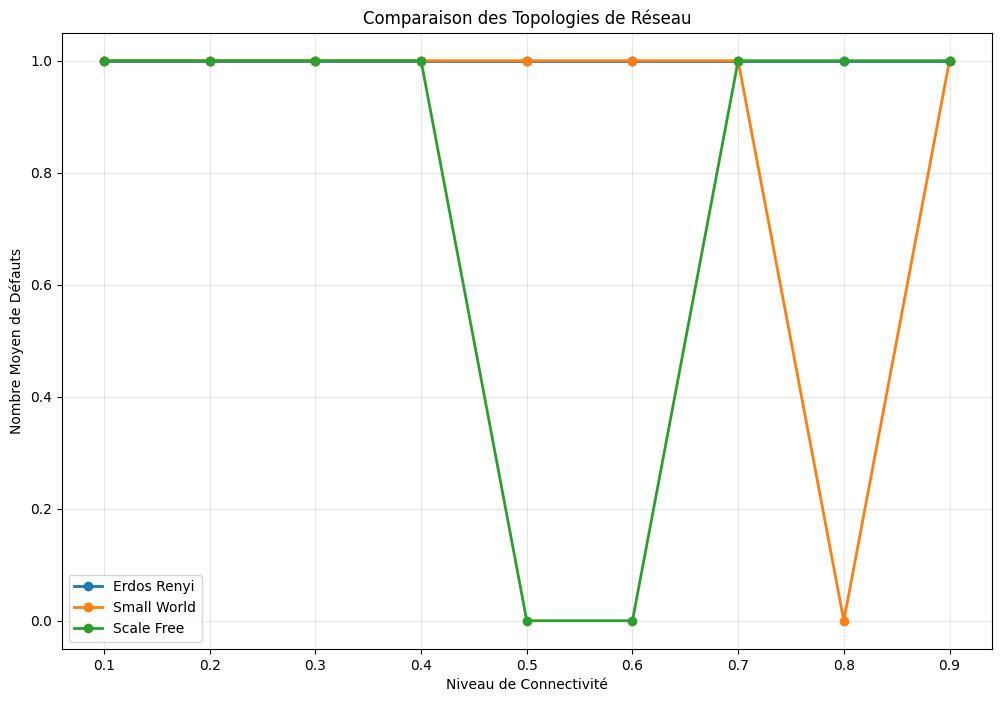


=== Analyse Correlated ===


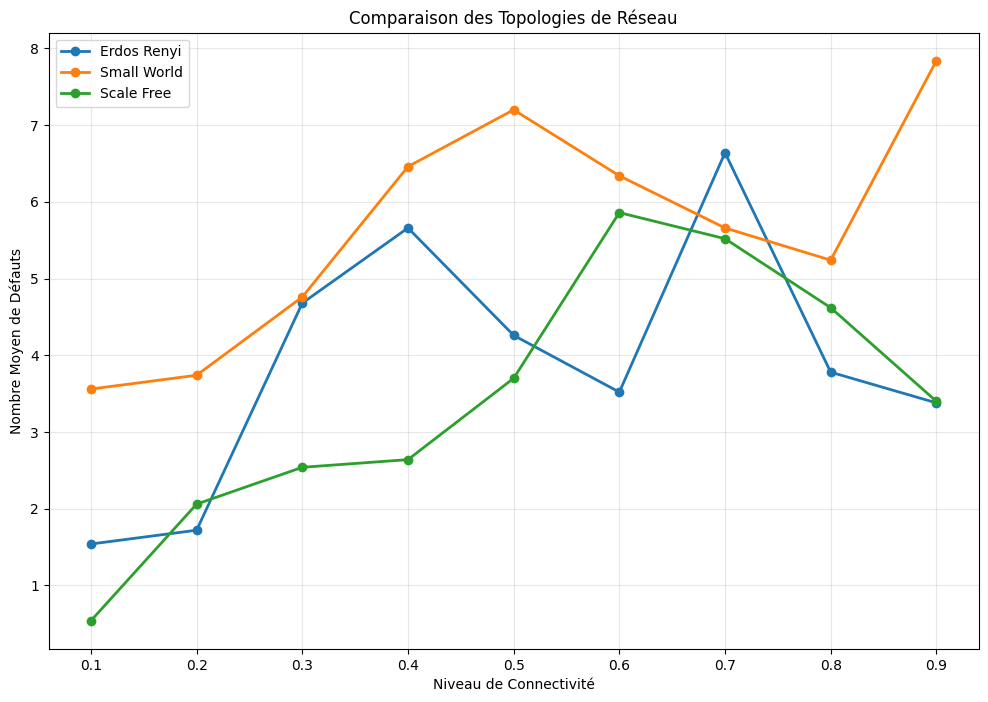

In [308]:

if __name__ == "__main__":
    def run_comparative_analysis(n_banks=50, connectivity_base=0.15):
        """Lance une analyse comparative complète et concise."""

        # Configuration automatique des réseaux (paramètres calibrés automatiquement)
        topologies = [
            NetworkTopology.ERDOS_RENYI,
            NetworkTopology.SMALL_WORLD,
            NetworkTopology.SCALE_FREE
        ]

        # Modèles de chocs à tester
        shock_models = [
            TargetedShockModel("systemic"),
            CorrelatedShockModel(correlation_strength=0.4)
        ]

        connectivity_range = np.linspace(0.1, 0.9, 9)

        # Analyse pour chaque modèle de choc
        for shock_model in shock_models:
            shock_name = shock_model.__class__.__name__.replace('ShockModel', '')
            print(f"\n=== Analyse {shock_name} ===")

            simulators = {}
            for topology in topologies:
                network = BankingNetwork(
                    number_bank=n_banks,
                    topology=topology,
                    probability_of_linking=connectivity_base
                    # Paramètres k, m, p calibrés automatiquement
                )

                simulators[topology.value.replace('_', ' ').title()] = \
                    BankingSimulator(network, shock_model)

            # Visualisation comparative
            BankingVisualizer.plot_topology_comparison(simulators, connectivity_range)

    # Lancement de l'analyse
    run_comparative_analysis(n_banks=100, connectivity_base=0.5)

1. Analyse principale...
=== Analyse de la Non-Monotonicité ===
Range de connectivité: 0.00 à 1.00
Nombre de simulations par point: 100
Progression: 1/51 (p=0.000)
Progression: 2/51 (p=0.020)
Progression: 3/51 (p=0.040)
Progression: 4/51 (p=0.060)
Progression: 5/51 (p=0.080)
Progression: 6/51 (p=0.100)
Progression: 7/51 (p=0.120)
Progression: 8/51 (p=0.140)
Progression: 9/51 (p=0.160)
Progression: 10/51 (p=0.180)
Progression: 11/51 (p=0.200)
Progression: 12/51 (p=0.220)
Progression: 13/51 (p=0.240)
Progression: 14/51 (p=0.260)
Progression: 15/51 (p=0.280)
Progression: 16/51 (p=0.300)
Progression: 17/51 (p=0.320)
Progression: 18/51 (p=0.340)
Progression: 19/51 (p=0.360)
Progression: 20/51 (p=0.380)
Progression: 21/51 (p=0.400)
Progression: 22/51 (p=0.420)
Progression: 23/51 (p=0.440)
Progression: 24/51 (p=0.460)
Progression: 25/51 (p=0.480)
Progression: 26/51 (p=0.500)
Progression: 27/51 (p=0.520)
Progression: 28/51 (p=0.540)
Progression: 29/51 (p=0.560)
Progression: 30/51 (p=0.580)
Pro

/tmp/ipykernel_14702/3251528207.py:295: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


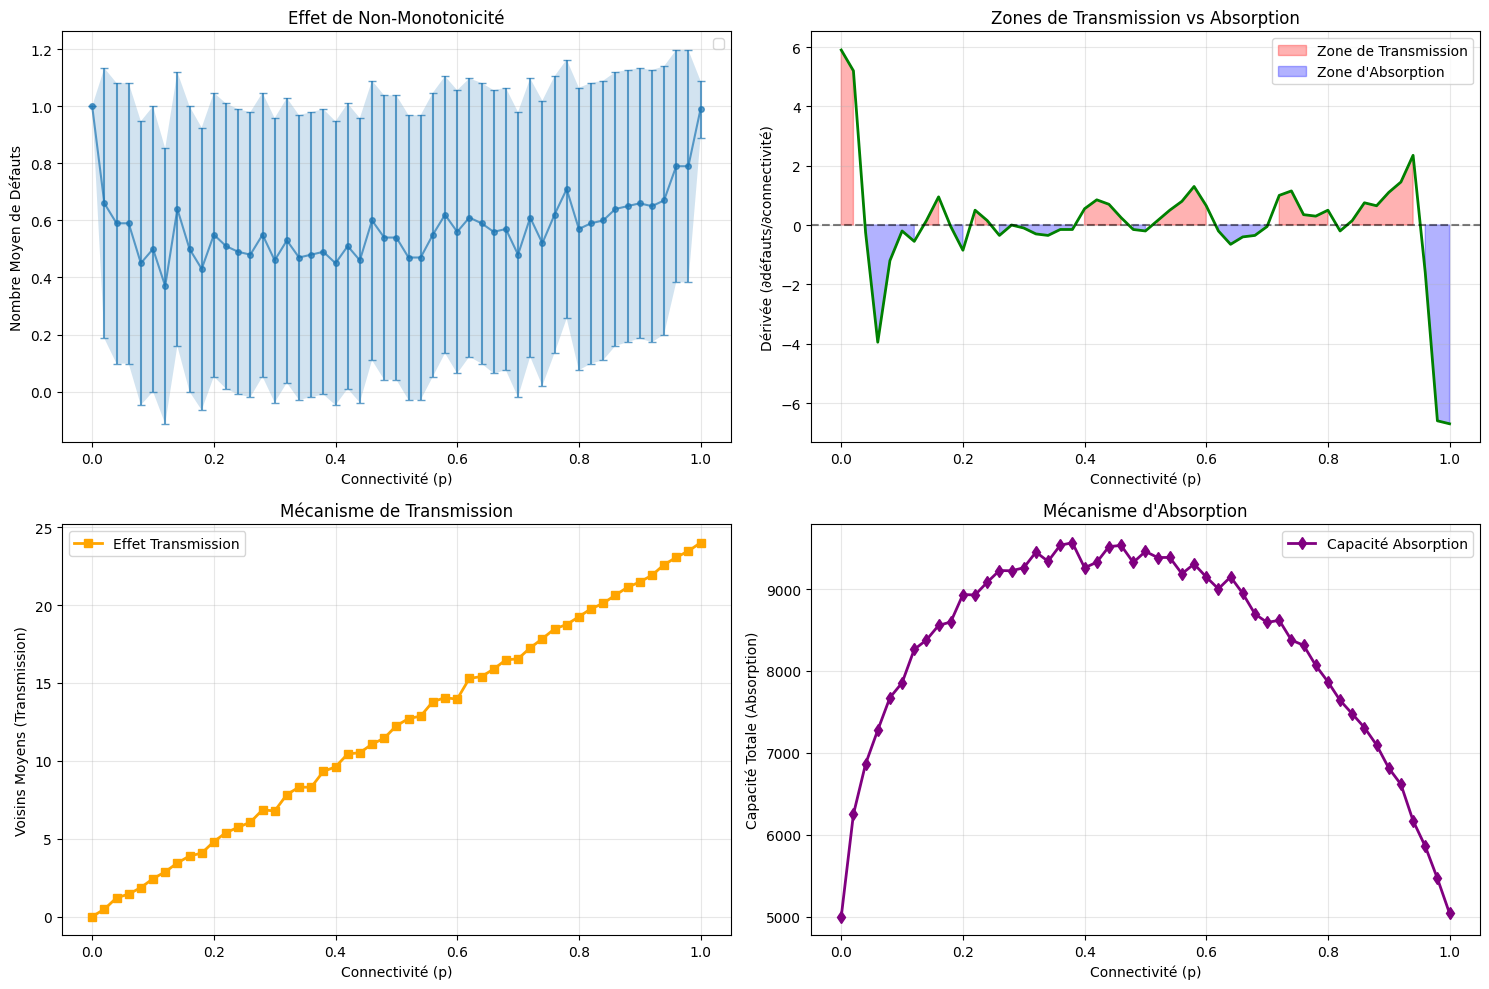

2. Analyse par capitalisation...

=== Comparaison par Niveau de Capitalisation ===
Niveau de capitalisation: 0.7x
Niveau de capitalisation: 1.0x
Niveau de capitalisation: 1.5x
Niveau de capitalisation: 2.0x


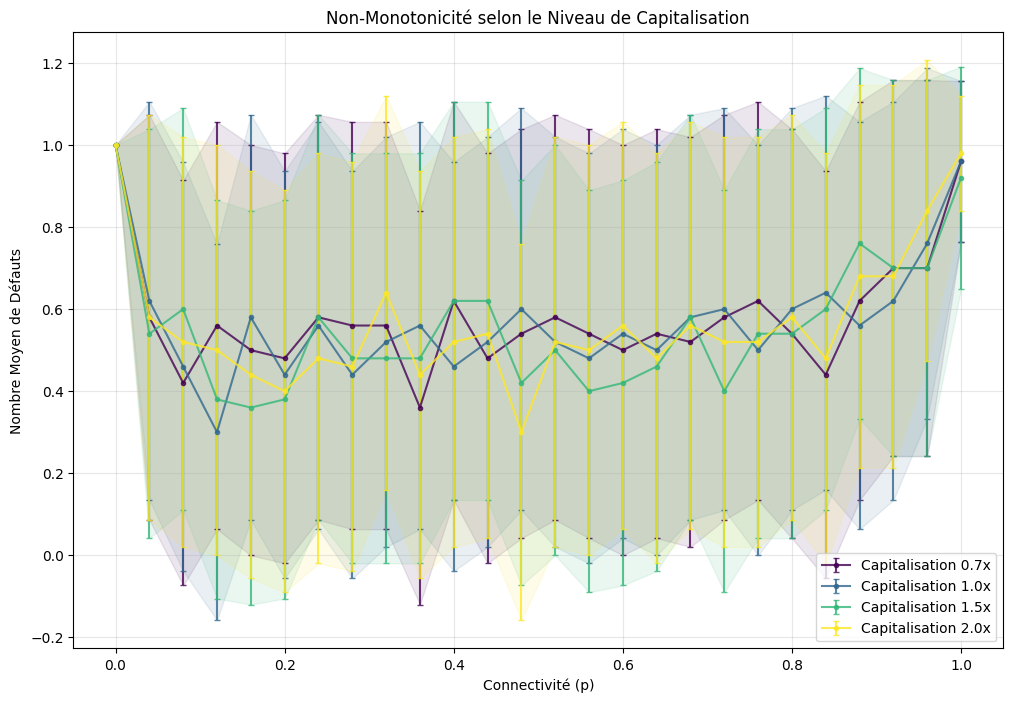


=== Analyse Terminée ===


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema
from scipy.stats import pearsonr
import seaborn as sns

def analyze_non_monotonicity(simulator, connectivity_range=None, n_simulations=100):
    """
    Analyse détaillée de l'effet de non-monotonicité de la connectivité.
    Reproduit et quantifie l'effet en M du papier Bank of England.
    """

    if connectivity_range is None:
        connectivity_range = np.linspace(0.0, 1.0, 51)  # Résolution fine

    print("=== Analyse de la Non-Monotonicité ===")
    print(f"Range de connectivité: {connectivity_range[0]:.2f} à {connectivity_range[-1]:.2f}")
    print(f"Nombre de simulations par point: {n_simulations}")

    # Stockage des résultats
    results = {
        'connectivity': connectivity_range,
        'mean_defaults': [],
        'std_defaults': [],
        'transmission_effects': [],
        'absorption_effects': []
    }

    original_prob = simulator.network.probability_of_linking

    for i, prob in enumerate(connectivity_range):
        print(f"Progression: {i+1}/{len(connectivity_range)} (p={prob:.3f})")

        simulator.network.probability_of_linking = prob

        defaults_runs = []
        transmission_measures = []
        absorption_measures = []

        for _ in range(n_simulations):
            simulator.network.generate()

            # Simulation principale
            result = simulator.single_simulation()
            defaults_runs.append(result['defaults_count'])

            # Mesures spécifiques pour comprendre les mécanismes
            if result['shock_metadata']['type'] == 'targeted':
                target = result['shock_metadata']['target']

                # Transmission : nombre de voisins de la banque ciblée qui peuvent recevoir le choc
                out_neighbors = list(simulator.network.graph.successors(target))  # Banques créancières
                transmission_measures.append(len(out_neighbors))

                # Absorption : capacité totale de net worth du réseau
                # Utilise un choc nul pour calculer le net worth de base
                zero_shock = np.zeros(simulator.network.number_bank)
                net_worth_vector, _ = simulator.network.get_net_worth_after_clearing(zero_shock)

                # Capacité d'absorption = net worth total positif du système
                positive_net_worth = np.sum(np.maximum(net_worth_vector, 0))
                absorption_measures.append(positive_net_worth)

        results['mean_defaults'].append(np.mean(defaults_runs))
        results['std_defaults'].append(np.std(defaults_runs))
        results['transmission_effects'].append(np.mean(transmission_measures))
        results['absorption_effects'].append(np.mean(absorption_measures))

    # Restaure la probabilité originale
    simulator.network.probability_of_linking = original_prob

    # Analyse des propriétés de non-monotonicité
    monotonicity_analysis = detect_non_monotonicity(results)

    return results, monotonicity_analysis


def detect_non_monotonicity(results):
    """
    Détecte et quantifie les propriétés de non-monotonicité avec des critères rigoureux.
    """
    connectivity = np.array(results['connectivity'])
    defaults = np.array(results['mean_defaults'])
    std_defaults = np.array(results['std_defaults'])

    # 1. Lissage pour réduire le bruit (moyenne mobile)
    window_size = max(3, len(defaults) // 10)
    defaults_smooth = np.convolve(defaults, np.ones(window_size)/window_size, mode='same')

    # 2. Calcul de la dérivée sur données lissées
    derivative = np.gradient(defaults_smooth, connectivity)

    # 3. Détection des extrema avec seuil de significativité
    # Seuil basé sur l'écart-type moyen
    significance_threshold = np.mean(std_defaults) * 0.5

    # Extrema locaux significatifs
    maxima_indices = []
    minima_indices = []

    for i in range(1, len(defaults_smooth) - 1):
        # Maximum local
        if (defaults_smooth[i] > defaults_smooth[i-1] and
            defaults_smooth[i] > defaults_smooth[i+1] and
            abs(defaults_smooth[i] - min(defaults_smooth[i-1], defaults_smooth[i+1])) > significance_threshold):
            maxima_indices.append(i)

        # Minimum local
        if (defaults_smooth[i] < defaults_smooth[i-1] and
            defaults_smooth[i] < defaults_smooth[i+1] and
            abs(max(defaults_smooth[i-1], defaults_smooth[i+1]) - defaults_smooth[i]) > significance_threshold):
            minima_indices.append(i)

    maxima = [(connectivity[i], defaults_smooth[i]) for i in maxima_indices]
    minima = [(connectivity[i], defaults_smooth[i]) for i in minima_indices]

    # 4. Test rigoureux de monotonicité
    monotonicity_tests = test_monotonicity_rigorously(connectivity, defaults_smooth, derivative, std_defaults)

    # 5. Corrélation de rang (plus robuste au bruit)
    from scipy.stats import spearmanr
    spearman_corr, spearman_p = spearmanr(connectivity, defaults)

    analysis = {
        'maxima': maxima,
        'minima': minima,
        'derivative': derivative,
        'defaults_smooth': defaults_smooth,
        'significance_threshold': significance_threshold,
        'monotonicity_tests': monotonicity_tests,
        'spearman_correlation': spearman_corr,
        'spearman_p_value': spearman_p
    }

    # Impression des résultats avec justification
    print("\n=== Analyse Rigoureuse de Non-Monotonicité ===")
    print(f"Seuil de significativité: {significance_threshold:.3f}")
    print(f"Extrema significatifs: {len(maxima)} maxima, {len(minima)} minima")
    print(f"Corrélation de Spearman: {spearman_corr:.3f} (p={spearman_p:.3f})")

    # Décision finale basée sur critères multiples
    is_non_monotonic = determine_non_monotonicity(analysis)

    if is_non_monotonic:
        print("✓ Non-monotonicité confirmée")
        print(f"  Justification: {analysis['monotonicity_tests']['justification']}")
    else:
        print("✗ Comportement monotone ou non-significatif")
        print(f"  Raison: {analysis['monotonicity_tests']['reason']}")

    return analysis


def test_monotonicity_rigorously(connectivity, defaults, derivative, std_defaults):
    """
    Tests rigoureux de monotonicité avec critères statistiques.
    """

    # Test 1: Nombre de changements de signe significatifs de la dérivée
    sign_derivative = np.sign(derivative)
    sign_changes = np.sum(np.abs(np.diff(sign_derivative)) > 0)

    # Test 2: Amplitude des changements (doivent être > bruit)
    noise_level = np.mean(std_defaults)
    significant_changes = 0
    for i in range(1, len(derivative)):
        if (np.sign(derivative[i]) != np.sign(derivative[i-1]) and
            abs(derivative[i]) > noise_level * 0.1):
            significant_changes += 1

    # Test 3: Test de runs (séquences montantes/descendantes)
    runs_test = runs_test_monotonicity(defaults)

    # Test 4: Variance de la dérivée (élevée = non-monotone)
    derivative_variance = np.var(derivative)
    variance_threshold = (np.max(defaults) - np.min(defaults)) / len(defaults)

    tests = {
        'sign_changes': sign_changes,
        'significant_changes': significant_changes,
        'runs_test': runs_test,
        'derivative_variance': derivative_variance,
        'variance_threshold': variance_threshold
    }

    # Critères de décision
    criteria = {
        'multiple_extrema': significant_changes >= 2,
        'high_variance': derivative_variance > variance_threshold,
        'runs_suggest_non_monotonic': runs_test['is_non_monotonic'],
        'sufficient_changes': sign_changes >= 4  # Au moins 2 pics/creux
    }

    # Justification de la décision
    positive_criteria = sum(criteria.values())

    if positive_criteria >= 3:
        justification = f"{positive_criteria}/4 critères satisfaits"
        reason = ""
    elif positive_criteria >= 2:
        justification = f"{positive_criteria}/4 critères satisfaits (limite)"
        reason = ""
    else:
        justification = ""
        reason = f"Seulement {positive_criteria}/4 critères satisfaits"

    tests.update({
        'criteria': criteria,
        'positive_criteria': positive_criteria,
        'justification': justification,
        'reason': reason
    })

    return tests


def runs_test_monotonicity(data):
    """
    Test de runs pour détecter la non-monotonicité.
    Une séquence monotone devrait avoir peu de "runs" (changements de direction).
    """
    # Calcule les différences
    diffs = np.diff(data)

    # Classifie comme montant (+1) ou descendant (-1)
    runs = np.sign(diffs)
    runs = runs[runs != 0]  # Ignore les plateaux

    # Compte les runs (séquences de même signe)
    if len(runs) == 0:
        return {'num_runs': 0, 'is_non_monotonic': False}

    run_changes = np.sum(np.diff(runs) != 0) + 1

    # Pour une fonction monotone, on s'attend à 1 seul run
    # Pour non-monotone, plusieurs runs
    expected_runs_monotonic = 1

    return {
        'num_runs': run_changes,
        'is_non_monotonic': run_changes > 2,  # Plus de 2 runs = non-monotone
        'monotonic_threshold': expected_runs_monotonic
    }


def determine_non_monotonicity(analysis):
    """
    Décision finale basée sur l'ensemble des tests.
    """
    tests = analysis['monotonicity_tests']

    # Critères principaux
    has_significant_extrema = len(analysis['maxima']) >= 1 and len(analysis['minima']) >= 1
    meets_statistical_criteria = tests['positive_criteria'] >= 2
    low_correlation = abs(analysis['spearman_correlation']) < 0.7

    # Décision: au moins 2 des 3 critères doivent être satisfaits
    decision_score = sum([has_significant_extrema, meets_statistical_criteria, low_correlation])

    return decision_score >= 2


def plot_non_monotonicity_detailed(results, monotonicity_analysis):
    """
    Visualisation complète de l'effet de non-monotonicité.
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    connectivity = results['connectivity']
    mean_defaults = results['mean_defaults']
    std_defaults = results['std_defaults']

    # 1. Courbe principale avec zones identifiées
    ax1 = axes[0, 0]
    ax1.errorbar(connectivity, mean_defaults, yerr=std_defaults,
                marker='o', markersize=4, alpha=0.7, capsize=3)
    ax1.fill_between(connectivity,
                    np.array(mean_defaults) - np.array(std_defaults),
                    np.array(mean_defaults) + np.array(std_defaults),
                    alpha=0.2)

    # Marquer les extrema
    for conn, defaults in monotonicity_analysis['maxima']:
        ax1.scatter(conn, defaults, color='red', s=100, marker='^',
                   label='Maximum local' if conn == monotonicity_analysis['maxima'][0][0] else "")

    for conn, defaults in monotonicity_analysis['minima']:
        ax1.scatter(conn, defaults, color='blue', s=100, marker='v',
                   label='Minimum local' if conn == monotonicity_analysis['minima'][0][0] else "")

    ax1.set_xlabel('Connectivité (p)')
    ax1.set_ylabel('Nombre Moyen de Défauts')
    ax1.set_title('Effet de Non-Monotonicité')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # 2. Dérivée pour montrer les zones de transmission/absorption
    ax2 = axes[0, 1]
    ax2.plot(connectivity, monotonicity_analysis['derivative'],
            color='green', linewidth=2)
    ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax2.fill_between(connectivity, 0, monotonicity_analysis['derivative'],
                    where=(monotonicity_analysis['derivative'] > 0),
                    color='red', alpha=0.3, label='Zone de Transmission')
    ax2.fill_between(connectivity, 0, monotonicity_analysis['derivative'],
                    where=(monotonicity_analysis['derivative'] < 0),
                    color='blue', alpha=0.3, label='Zone d\'Absorption')
    ax2.set_xlabel('Connectivité (p)')
    ax2.set_ylabel('Dérivée (∂défauts/∂connectivité)')
    ax2.set_title('Zones de Transmission vs Absorption')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    # 3. Effets de transmission
    ax3 = axes[1, 0]
    ax3.plot(connectivity, results['transmission_effects'],
            color='orange', marker='s', linewidth=2, label='Effet Transmission')
    ax3.set_xlabel('Connectivité (p)')
    ax3.set_ylabel('Voisins Moyens (Transmission)')
    ax3.set_title('Mécanisme de Transmission')
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    # 4. Effets d'absorption
    ax4 = axes[1, 1]
    ax4.plot(connectivity, results['absorption_effects'],
            color='purple', marker='d', linewidth=2, label='Capacité Absorption')
    ax4.set_xlabel('Connectivité (p)')
    ax4.set_ylabel('Capacité Totale (Absorption)')
    ax4.set_title('Mécanisme d\'Absorption')
    ax4.grid(True, alpha=0.3)
    ax4.legend()

    plt.tight_layout()
    plt.show()


def compare_capitalization_levels(simulator, n_simulations=50):
    """
    Compare l'effet de non-monotonicité pour différents niveaux de capitalisation.
    Reproduit le graphique du papier avec plusieurs courbes de net worth.
    """
    print("\n=== Comparaison par Niveau de Capitalisation ===")

    connectivity_range = np.linspace(0.0, 1.0, 26)
    capitalization_levels = [0.7, 1.0, 1.5, 2.0]  # Multiplicateurs des actifs

    fig, ax = plt.subplots(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0, 1, len(capitalization_levels)))

    original_assets = simulator.network.vector_outside_asset.copy()

    for i, cap_level in enumerate(capitalization_levels):
        print(f"Niveau de capitalisation: {cap_level}x")

        # Ajuste la capitalisation
        simulator.network.vector_outside_asset = original_assets * cap_level

        mean_defaults = []
        std_defaults = []

        for prob in connectivity_range:
            simulator.network.probability_of_linking = prob

            defaults_runs = []
            for _ in range(n_simulations):
                simulator.network.generate()
                result = simulator.single_simulation()
                defaults_runs.append(result['defaults_count'])

            mean_defaults.append(np.mean(defaults_runs))
            std_defaults.append(np.std(defaults_runs))

        # Trace la courbe
        ax.errorbar(connectivity_range, mean_defaults, yerr=std_defaults,
                   color=colors[i], marker='o', markersize=3, alpha=0.8,
                   label=f'Capitalisation {cap_level}x', capsize=2)

        # Zone d'incertitude
        ax.fill_between(connectivity_range,
                       np.array(mean_defaults) - np.array(std_defaults),
                       np.array(mean_defaults) + np.array(std_defaults),
                       color=colors[i], alpha=0.1)

    # Restaure les actifs originaux
    simulator.network.vector_outside_asset = original_assets

    ax.set_xlabel('Connectivité (p)')
    ax.set_ylabel('Nombre Moyen de Défauts')
    ax.set_title('Non-Monotonicité selon le Niveau de Capitalisation')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()


def run_complete_non_monotonicity_analysis():
    """
    Lance une analyse complète de la non-monotonicité.
    """

    # Configuration
    network = BankingNetwork(
        number_bank=25,  # Comme dans le papier
        topology=NetworkTopology.ERDOS_RENYI,
        probability_of_linking=0.2
    )

    shock_model = TargetedShockModel(target_strategy="random", shock_intensity=1.0)
    simulator = BankingSimulator(network, shock_model)

    # 1. Analyse principale de non-monotonicité
    print("1. Analyse principale...")
    results, analysis = analyze_non_monotonicity(simulator, n_simulations=100)
    plot_non_monotonicity_detailed(results, analysis)

    # 2. Comparaison par niveaux de capitalisation
    print("2. Analyse par capitalisation...")
    compare_capitalization_levels(simulator, n_simulations=50)

    print("\n=== Analyse Terminée ===")
    return results, analysis


# Lancement de l'analyse
if __name__ == "__main__":
    results, analysis = run_complete_non_monotonicity_analysis()